# Real-Time Multi-Step Temperature Forecasting System

## Executive Summary

This project develops a **multi-step temperature forecasting pipeline** for the **Downtown district (`D01`)**, generating temperature forecasts across a **6-hour horizon** ($t+1$ through $t+6$). The modeling approach uses **Multi-Output Linear Regression**, where a single regression model learns to predict six future temperature targets simultaneously.

The objective is to transform hourly weather observations into a deployment-ready feature matrix, preserve temporal structure through cyclical encodings, reduce the influence of highly skewed physical variables, align future targets without leakage, and evaluate forecast quality independently at each horizon.

> **Scope note:** The current notebook visibly implements timestamp parsing, Downtown filtering, outlier handling, logarithmic transformations, target shifting, cyclical time encoding, categorical one-hot encoding, chronological splitting, multi-output linear regression, evaluation, and model serialization. A group-wise temporal interpolation step is **not present in the executed cells shown here**, so it should be treated as a documented preprocessing consideration rather than an executed transformation in this notebook.

## Pipeline Architecture

**Ingestion → Profiling → Preprocessing → Feature Engineering → Target Generation → Training & Evaluation → Export**

| Stage | Purpose |
|---|---|
| **Ingestion** | Load the processed weather dataset into a Pandas DataFrame |
| **Profiling** | Inspect dimensions, types, duplicates, missing values, and distributions |
| **Preprocessing** | Parse timestamps, validate percentage ranges, isolate Downtown observations, and address outliers |
| **Feature Engineering** | Add log-transformed physical variables, cyclical time features, and categorical encodings |
| **Target Generation** | Construct six future-temperature targets using temporal shifts |
| **Training & Evaluation** | Perform an ordered 80/20 split and fit/evaluate a multi-output Linear Regression model |
| **Export** | Serialize the trained model and expected feature schema with `joblib` |


## 1. Environment Setup

The notebook uses a compact Python data-science stack covering data manipulation, numerical computation, visualization, automated profiling, machine learning, and artifact serialization.

| Library | Role in the pipeline |
|---|---|
| **Pandas** | Data ingestion, tabular manipulation, datetime handling, filtering, feature construction, and evaluation tables |
| **NumPy** | Numerical transformations, trigonometric encodings, logarithmic transformations, and metric calculations |
| **Matplotlib / Seaborn** | Exploratory visualization, particularly box plots used to inspect feature distributions and outliers |
| **scikit-learn** | Linear Regression training and MAE, RMSE, and $R^2$ evaluation |
| **joblib** | Serialization and later reloading of the trained model package for deployment |

The environment is intentionally lightweight: the final estimator is a classical linear model, making the resulting artifact relatively simple to inspect, serialize, and execute.


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
%matplotlib inline

C:\Users\DELL\AppData\Local\Temp\ipykernel_21320\430545469.py:8: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Creating Helping Fuction To Visualize Info of DataFrame

In [2]:
def profile_dataframe(df, name = 'Data Frame'):
    print(f"{'='*18} {name} {'='*18}")
    print(f"Shape: {df.shape}")
    print(f"Duplicate rows: {df.duplicated().sum():,}")
    print("\nDtypes:")
    display(df.dtypes.to_frame("dtype"))
    print("Missing values:")
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing[missing > 0].to_frame("missing_count"))
    print("Sample:")
    display(df.head())


Reading DataFrame

## 2. Data Ingestion & Profiling

The pipeline begins by loading `weather_processed.csv` into a Pandas DataFrame. Before modeling, the notebook performs a structured inspection of the dataset:

- **Shape:** verifies the number of observations and variables.
- **Duplicate rows:** checks for repeated records.
- **Data types:** identifies numeric, categorical, and temporal fields.
- **Missing values:** quantifies null observations by column.
- **Sample records:** confirms the structure and content of the imported data.

This stage establishes the data-quality baseline before any modeling transformations are applied.

### Timestamp Standardization

The raw `timestamp` field is converted to Pandas datetime format. A consistent temporal representation is essential because subsequent operations depend on chronological ordering and extraction of **hour** and **month** components.


In [3]:
df = pd.read_csv('weather_processed.csv')
df.head()

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status,district_name
0,01/01/2023 00:00,D01,-2.114558,-1.269328,64.790494,0.0,2.755095,46.435298,Partly Cloudy,0,0,0,Normal,Downtown
1,01/01/2023 01:00,D01,-1.071947,-0.618360,53.497799,0.0,2.819884,0.000000,Clear,0,0,0,Normal,Downtown
2,01/01/2023 02:00,D01,1.417415,0.012752,61.348556,0.0,8.009989,31.153514,Partly Cloudy,0,0,0,Normal,Downtown
3,01/01/2023 03:00,D01,0.118787,1.425774,65.823608,0.0,7.983536,17.997245,Clear,0,0,0,Normal,Downtown
4,01/01/2023 04:00,D01,3.300550,2.168793,40.948678,0.0,13.769042,37.010263,Partly Cloudy,0,0,0,Normal,Downtown


In [4]:
profile_dataframe(df, 'Weather')

================== Weather ==================
Shape: (526080, 14)
Duplicate rows: 0

Dtypes:


,dtype
timestamp,object
district_id,object
temperature_c,float64
feels_like_c,float64
humidity_percent,float64
rainfall_mm,float64
wind_speed_kmh,float64
cloud_cover_percent,float64
weather_condition,object
heatwave_flag,int64


Missing values:


,missing_count


Sample:


,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status,district_name
0,01/01/2023 00:00,D01,-2.114558,-1.269328,64.790494,0.0,2.755095,46.435298,Partly Cloudy,0,0,0,Normal,Downtown
1,01/01/2023 01:00,D01,-1.071947,-0.618360,53.497799,0.0,2.819884,0.000000,Clear,0,0,0,Normal,Downtown
2,01/01/2023 02:00,D01,1.417415,0.012752,61.348556,0.0,8.009989,31.153514,Partly Cloudy,0,0,0,Normal,Downtown
3,01/01/2023 03:00,D01,0.118787,1.425774,65.823608,0.0,7.983536,17.997245,Clear,0,0,0,Normal,Downtown
4,01/01/2023 04:00,D01,3.300550,2.168793,40.948678,0.0,13.769042,37.010263,Partly Cloudy,0,0,0,Normal,Downtown


Transform timestamp into Datetime 

## 3. Data Preprocessing & Cleaning

### Temporal and Sensor Data Quality

For time-series sensor data, missing observations can occur because of communication interruptions or sensor dropouts. A common production preprocessing strategy is **group-wise temporal interpolation**: observations are ordered by timestamp within each district, and short gaps are interpolated using neighboring measurements while preserving district boundaries.

**Important implementation note:** the current notebook does not contain an executed interpolation statement. Its actual cleaning logic instead performs timestamp conversion, range validation, district selection, and outlier treatment. If interpolation is required for the production pipeline, it should be implemented explicitly before target construction.

### Physical Range Validation

Percentage-based measurements are checked against their physically meaningful bounds:

$$0 \leq \text{humidity\_percent} \leq 100$$

$$0 \leq \text{cloud\_cover\_percent} \leq 100$$

The notebook reports that no errors were found in these percentage columns.

### District Selection

The modeling scope is restricted to **Downtown**, corresponding to the requested Downtown forecasting task (`D01`). Filtering to a single district reduces spatial heterogeneity and makes the learned relationship specific to that location.


In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'] , format = 'mixed')

In [6]:
df['timestamp'].head()

0   2023-01-01 00:00:00
1   2023-01-01 01:00:00
2   2023-01-01 02:00:00
3   2023-01-01 03:00:00
4   2023-01-01 04:00:00
Name: timestamp, dtype: datetime64[ns]

In [7]:
non_neg_col = ['humidity_percent',]

# Feature Engineering

## 4. Feature Engineering

Feature engineering converts raw weather observations into representations that are more suitable for a linear model while retaining physically meaningful temporal structure.

### 4.1 Cyclical Time Encoding

Hour and month are periodic variables: hour 23 is adjacent to hour 0, and month 12 is adjacent to month 1. Treating these values as ordinary integers would incorrectly imply that the numerical distance between 23 and 0 is large.

The notebook therefore maps each periodic variable onto the unit circle.

For hour:

$$
\text{hour\_sin}=\sin\left(\frac{2\pi\,\text{hour}}{24}\right),
\qquad
\text{hour\_cos}=\cos\left(\frac{2\pi\,\text{hour}}{24}\right)
$$

For month:

$$
\text{month\_sin}=\sin\left(\frac{2\pi\,\text{month}}{12}\right),
\qquad
\text{month\_cos}=\cos\left(\frac{2\pi\,\text{month}}{12}\right)
$$

Using both sine and cosine preserves the phase of the cycle while avoiding an artificial discontinuity at the period boundary.

### 4.2 Logarithmic Transformations

Rainfall and wind speed can be highly right-skewed, with many relatively small observations and fewer large values. The notebook applies:

$$x' = \log(1+x)$$

using `np.log1p`, producing `rainfall_log` and `wind_speed_log`.

This transformation compresses extreme magnitudes and can make relationships more amenable to a linear model while retaining zero-valued observations.

### 4.3 Categorical Encoding

The categorical `weather_condition` variable is transformed using **One-Hot Encoding** with `drop_first=True`. This converts categories into binary indicator features while omitting one reference category to avoid redundant perfect linear dependence in the design matrix.

The final feature matrix therefore combines numeric weather measurements, transformed physical variables, cyclical temporal features, and encoded weather-condition indicators.


In [8]:
numerical_cols_names = df.select_dtypes(include='number').columns
numerical_cols = df[numerical_cols_names]
numerical_cols

,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,heatwave_flag,heavy_rain_flag,storm_flag
0,-2.114558,-1.269328,64.790494,0.000000,2.755095,46.435298,0,0,0
1,-1.071947,-0.618360,53.497799,0.000000,2.819884,0.000000,0,0,0
2,1.417415,0.012752,61.348556,0.000000,8.009989,31.153514,0,0,0
3,0.118787,1.425774,65.823608,0.000000,7.983536,17.997245,0,0,0
4,3.300550,2.168793,40.948678,0.000000,13.769042,37.010263,0,0,0
...,...,...,...,...,...,...,...,...,...
526075,3.404984,2.567980,75.129534,0.000000,11.408312,49.728874,0,0,0
526076,2.557344,2.617756,45.813378,0.000000,7.446961,33.607246,0,0,0
526077,-2.209800,-1.976816,61.402841,0.000000,8.485763,43.804237,0,0,0
526078,-1.714643,-0.450025,41.643864,0.000000,5.531341,14.932425,0,0,0


In [9]:
df.loc[(df['humidity_percent'] > 100) | (df['humidity_percent'] < 0)]

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status,district_name


In [10]:
df.loc[(df['cloud_cover_percent'] > 100) | (df['cloud_cover_percent'] < 0)]

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status,district_name


No Errors in percent Columns

Selecting Downtown District to build the model

In [11]:
downtown_df = df.loc[df['district_name'] == 'Downtown'].copy()
downtown_df

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status,district_name
0,2023-01-01 00:00:00,D01,-2.114558,-1.269328,64.790494,0.000000,2.755095,46.435298,Partly Cloudy,0,0,0,Normal,Downtown
1,2023-01-01 01:00:00,D01,-1.071947,-0.618360,53.497799,0.000000,2.819884,0.000000,Clear,0,0,0,Normal,Downtown
2,2023-01-01 02:00:00,D01,1.417415,0.012752,61.348556,0.000000,8.009989,31.153514,Partly Cloudy,0,0,0,Normal,Downtown
3,2023-01-01 03:00:00,D01,0.118787,1.425774,65.823608,0.000000,7.983536,17.997245,Clear,0,0,0,Normal,Downtown
4,2023-01-01 04:00:00,D01,3.300550,2.168793,40.948678,0.000000,13.769042,37.010263,Partly Cloudy,0,0,0,Normal,Downtown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2025-12-31 19:00:00,D01,5.087360,6.406916,49.047318,0.000000,7.138798,44.626176,Partly Cloudy,0,0,0,Normal,Downtown
26300,2025-12-31 20:00:00,D01,4.185678,4.769986,32.499211,0.000000,4.329304,25.087092,Clear,0,0,0,Normal,Downtown
26301,2025-12-31 21:00:00,D01,2.187384,2.353730,48.937337,0.000000,3.091038,13.334909,Partly Cloudy,0,0,0,Communication-Loss,Downtown
26302,2025-12-31 22:00:00,D01,0.189089,-0.062526,65.375463,0.000000,1.852772,1.582725,Clear,0,0,0,Normal,Downtown


In [12]:
downtown_df.head()

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status,district_name
0,2023-01-01 00:00:00,D01,-2.114558,-1.269328,64.790494,0.0,2.755095,46.435298,Partly Cloudy,0,0,0,Normal,Downtown
1,2023-01-01 01:00:00,D01,-1.071947,-0.618360,53.497799,0.0,2.819884,0.000000,Clear,0,0,0,Normal,Downtown
2,2023-01-01 02:00:00,D01,1.417415,0.012752,61.348556,0.0,8.009989,31.153514,Partly Cloudy,0,0,0,Normal,Downtown
3,2023-01-01 03:00:00,D01,0.118787,1.425774,65.823608,0.0,7.983536,17.997245,Clear,0,0,0,Normal,Downtown
4,2023-01-01 04:00:00,D01,3.300550,2.168793,40.948678,0.0,13.769042,37.010263,Partly Cloudy,0,0,0,Normal,Downtown


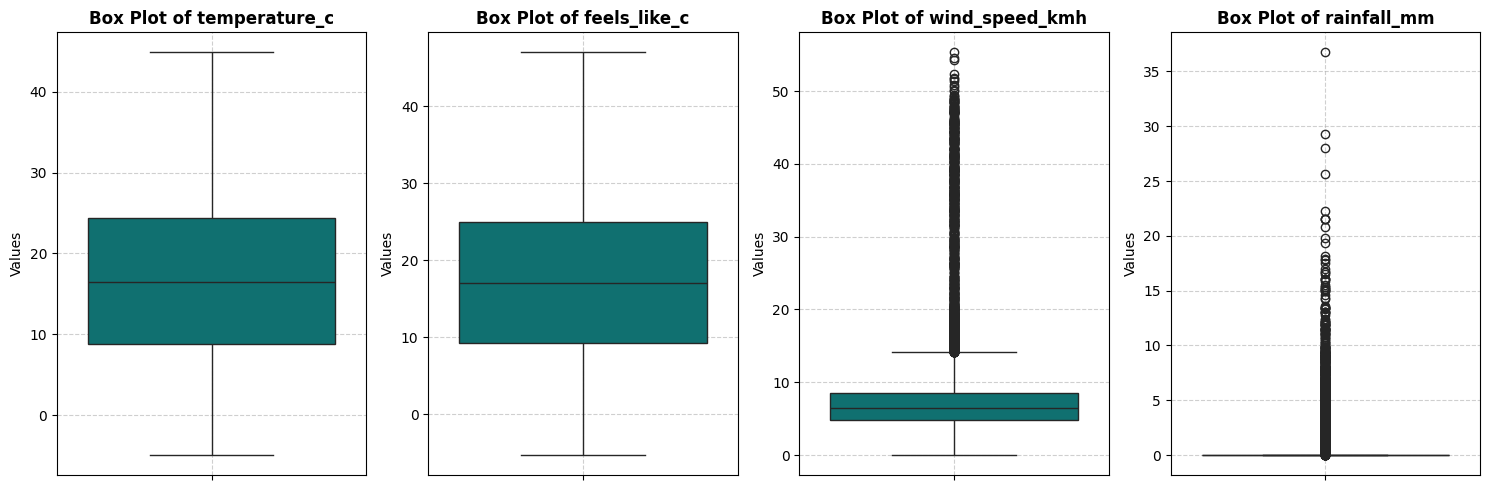

In [13]:
cols = ['temperature_c','feels_like_c','wind_speed_kmh','rainfall_mm']
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))

for i, col in enumerate(cols):
  sns.boxplot(y=downtown_df[col], ax=axes[i], color='teal')
  axes[i].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
  axes[i].set_ylabel('Values')
  axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

I will use Log Transformation transformation for wind_speed a rainfull_mm

In [14]:
downtown_df['rainfall_log'] = np.log1p(downtown_df['rainfall_mm'])
downtown_df['wind_speed_log'] = np.log1p(downtown_df['wind_speed_kmh'])
downtown_df

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status,district_name,rainfall_log,wind_speed_log
0,2023-01-01 00:00:00,D01,-2.114558,-1.269328,64.790494,0.000000,2.755095,46.435298,Partly Cloudy,0,0,0,Normal,Downtown,0.00000,1.323114
1,2023-01-01 01:00:00,D01,-1.071947,-0.618360,53.497799,0.000000,2.819884,0.000000,Clear,0,0,0,Normal,Downtown,0.00000,1.340220
2,2023-01-01 02:00:00,D01,1.417415,0.012752,61.348556,0.000000,8.009989,31.153514,Partly Cloudy,0,0,0,Normal,Downtown,0.00000,2.198334
3,2023-01-01 03:00:00,D01,0.118787,1.425774,65.823608,0.000000,7.983536,17.997245,Clear,0,0,0,Normal,Downtown,0.00000,2.195394
4,2023-01-01 04:00:00,D01,3.300550,2.168793,40.948678,0.000000,13.769042,37.010263,Partly Cloudy,0,0,0,Normal,Downtown,0.00000,2.692533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2025-12-31 19:00:00,D01,5.087360,6.406916,49.047318,0.000000,7.138798,44.626176,Partly Cloudy,0,0,0,Normal,Downtown,0.00000,2.096642
26300,2025-12-31 20:00:00,D01,4.185678,4.769986,32.499211,0.000000,4.329304,25.087092,Clear,0,0,0,Normal,Downtown,0.00000,1.673221
26301,2025-12-31 21:00:00,D01,2.187384,2.353730,48.937337,0.000000,3.091038,13.334909,Partly Cloudy,0,0,0,Communication-Loss,Downtown,0.00000,1.408799
26302,2025-12-31 22:00:00,D01,0.189089,-0.062526,65.375463,0.000000,1.852772,1.582725,Clear,0,0,0,Normal,Downtown,0.00000,1.048291


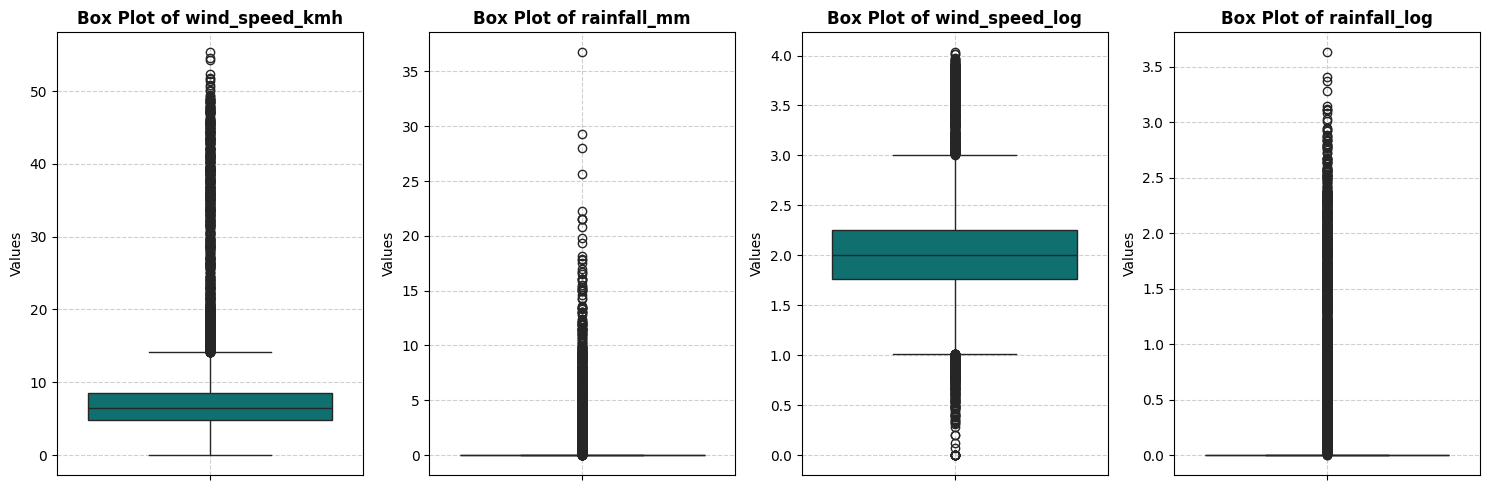

In [15]:
cols = ['wind_speed_kmh','rainfall_mm','wind_speed_log','rainfall_log']
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))

for i, col in enumerate(cols):
  sns.boxplot(y=downtown_df[col], ax=axes[i], color='teal')
  axes[i].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
  axes[i].set_ylabel('Values')
  axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Preparing X and y for the training

## 5. Multi-Horizon Target Alignment

The forecasting task is explicitly **multi-step**. Instead of predicting only the next observation, the notebook constructs six future targets:

$$
y = [T_{t+1}, T_{t+2}, T_{t+3}, T_{t+4}, T_{t+5}, T_{t+6}]
$$

Each target is created with a negative temporal shift:

```text
target_t_h = temperature_c.shift(-h)
```

for $h \in \{1,2,3,4,5,6\}$.

Conceptually, the current observation at time $t$ becomes aligned with the temperature observed $h$ hours later. The final six rows cannot provide a complete six-hour future horizon, so they are removed before training.

This alignment is critical: each feature row must correspond only to information available at the forecast origin, while the six target columns represent future outcomes.


In [16]:
target_cols = [f'target_t_{h}' for h in range(1, 7)]

for h in range(1, 7):
  downtown_df[f'target_t_{h}'] = downtown_df['temperature_c'].shift(-h)

print(downtown_df[['temperature_c'] + target_cols].head())


   temperature_c  target_t_1  target_t_2  target_t_3  target_t_4  target_t_5  \
0      -2.114558   -1.071947    1.417415    0.118787    3.300550    2.241127   
1      -1.071947    1.417415    0.118787    3.300550    2.241127    7.825429   
2       1.417415    0.118787    3.300550    2.241127    7.825429    8.440526   
3       0.118787    3.300550    2.241127    7.825429    8.440526    8.244961   
4       3.300550    2.241127    7.825429    8.440526    8.244961   12.471981   

   target_t_6  
0    7.825429  
1    8.440526  
2    8.244961  
3   12.471981  
4    9.373047  


In [17]:
downtown_df.isnull().sum()

timestamp              0
district_id            0
temperature_c          0
feels_like_c           0
humidity_percent       0
rainfall_mm            0
wind_speed_kmh         0
cloud_cover_percent    0
weather_condition      0
heatwave_flag          0
heavy_rain_flag        0
storm_flag             0
sensor_status          0
district_name          0
rainfall_log           0
wind_speed_log         0
target_t_1             1
target_t_2             2
target_t_3             3
target_t_4             4
target_t_5             5
target_t_6             6
dtype: int64

In [18]:
# Deleting the last 6 raws
downtown_df = downtown_df.dropna(subset=target_cols).reset_index(drop=True)
downtown_df.isnull().sum()

timestamp              0
district_id            0
temperature_c          0
feels_like_c           0
humidity_percent       0
rainfall_mm            0
wind_speed_kmh         0
cloud_cover_percent    0
weather_condition      0
heatwave_flag          0
heavy_rain_flag        0
storm_flag             0
sensor_status          0
district_name          0
rainfall_log           0
wind_speed_log         0
target_t_1             0
target_t_2             0
target_t_3             0
target_t_4             0
target_t_5             0
target_t_6             0
dtype: int64

In [19]:
downtown_df['timestamp'] = pd.to_datetime(downtown_df['timestamp'])

hours = downtown_df['timestamp'].dt.hour
months = downtown_df['timestamp'].dt.month

downtown_df['hour_sin'] = np.sin(2 * np.pi * hours / 24.0)
downtown_df['hour_cos'] = np.cos(2 * np.pi * hours / 24.0)

downtown_df['month_sin'] = np.sin(2 * np.pi * months / 12.0)
downtown_df['month_cos'] = np.cos(2 * np.pi * months / 12.0)


In [20]:
downtown_df.head()

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,...,target_t_1,target_t_2,target_t_3,target_t_4,target_t_5,target_t_6,hour_sin,hour_cos,month_sin,month_cos
0,2023-01-01 00:00:00,D01,-2.114558,-1.269328,64.790494,0.0,2.755095,46.435298,Partly Cloudy,0,...,-1.071947,1.417415,0.118787,3.300550,2.241127,7.825429,0.000000,1.000000,0.5,0.866025
1,2023-01-01 01:00:00,D01,-1.071947,-0.618360,53.497799,0.0,2.819884,0.000000,Clear,0,...,1.417415,0.118787,3.300550,2.241127,7.825429,8.440526,0.258819,0.965926,0.5,0.866025
2,2023-01-01 02:00:00,D01,1.417415,0.012752,61.348556,0.0,8.009989,31.153514,Partly Cloudy,0,...,0.118787,3.300550,2.241127,7.825429,8.440526,8.244961,0.500000,0.866025,0.5,0.866025
3,2023-01-01 03:00:00,D01,0.118787,1.425774,65.823608,0.0,7.983536,17.997245,Clear,0,...,3.300550,2.241127,7.825429,8.440526,8.244961,12.471981,0.707107,0.707107,0.5,0.866025
4,2023-01-01 04:00:00,D01,3.300550,2.168793,40.948678,0.0,13.769042,37.010263,Partly Cloudy,0,...,2.241127,7.825429,8.440526,8.244961,12.471981,9.373047,0.866025,0.500000,0.5,0.866025


## 6. Final Modeling Matrices

After target construction and feature engineering, the notebook explicitly separates the predictors **$X$** from the six-dimensional target matrix **$y$**.

The target columns are excluded from the feature matrix to prevent direct leakage of future temperatures. Additional exclusions remove fields considered redundant, constant, or replaced by transformed representations, including the raw timestamp, `feels_like_c`, raw rainfall, raw wind speed, and other specified columns.

`weather_condition` is one-hot encoded, and `district_name` is subsequently removed because the model is already restricted to Downtown.

### Modeling Contract

The resulting matrices follow the structure:

$$
X \in \mathbb{R}^{n \times p},
\qquad
y \in \mathbb{R}^{n \times 6}
$$

where $n$ is the number of valid Downtown observations and $p$ is the number of engineered predictor variables.

The notebook profiles both final matrices before training, providing a final data-quality checkpoint.


In [21]:
target_cols = [f'target_t_{h}' for h in range(1, 7)]

valid_df = downtown_df.dropna(subset=target_cols).copy()

y = valid_df[target_cols].copy()

cols_to_drop_from_x = target_cols + [
    'district_id',  # Constant value (zero variance)
    'district_name',# Constant value (zero variance)
    'feels_like_c',  # High multicollinearity with temperature_c
    'rainfall_mm',  # Replaced by log-transformed version / flags
    'wind_speed_kmh',  # Replaced by log-transformed version
    'sensor_status',  # Constant/redundant status flag if not needed
    'timestamp',  # Raw datetime is already decomposed into cyclical features
]

X = valid_df.drop(
    columns=[col for col in cols_to_drop_from_x if col in valid_df.columns]
)

if 'weather_condition' in X.columns:
  X = pd.get_dummies(
      X, columns=['weather_condition'], drop_first=True, dtype=int
  )

print(f'Original downtown_df shape (untouched): {downtown_df.shape}')
print(f'Features matrix X shape: {X.shape}')
print(f'Targets matrix y shape: {y.shape}')
print('\nFinal features in X:')
print(X.columns.tolist())

Original downtown_df shape (untouched): (26298, 26)
Features matrix X shape: (26298, 18)
Targets matrix y shape: (26298, 6)

Final features in X:
['temperature_c', 'humidity_percent', 'cloud_cover_percent', 'heatwave_flag', 'heavy_rain_flag', 'storm_flag', 'rainfall_log', 'wind_speed_log', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weather_condition_Cloudy', 'weather_condition_Heatwave', 'weather_condition_Heavy Rain', 'weather_condition_Partly Cloudy', 'weather_condition_Rain', 'weather_condition_Storm']


In [22]:
profile_dataframe(X)
profile_dataframe(y)

================== Data Frame ==================
Shape: (26298, 18)
Duplicate rows: 0

Dtypes:


,dtype
temperature_c,float64
humidity_percent,float64
cloud_cover_percent,float64
heatwave_flag,int64
heavy_rain_flag,int64
storm_flag,int64
rainfall_log,float64
wind_speed_log,float64
hour_sin,float64
hour_cos,float64


Missing values:


,missing_count


Sample:


...

,dtype
target_t_1,float64
target_t_2,float64
target_t_3,float64
target_t_4,float64
target_t_5,float64
target_t_6,float64


Missing values:


,missing_count


Sample:


,target_t_1,target_t_2,target_t_3,target_t_4,target_t_5,target_t_6
0,-1.071947,1.417415,0.118787,3.300550,2.241127,7.825429
1,1.417415,0.118787,3.300550,2.241127,7.825429,8.440526
2,0.118787,3.300550,2.241127,7.825429,8.440526,8.244961
3,3.300550,2.241127,7.825429,8.440526,8.244961,12.471981
4,2.241127,7.825429,8.440526,8.244961,12.471981,9.373047


# Training The Model

## 7. Model Training & Time-Series Validation

### Chronological Train/Test Split

The dataset is divided chronologically:

- **80%** of observations → training set
- **20%** of observations → test set

The split uses positional slicing rather than random shuffling. This is essential for time-series forecasting because random splitting can place future observations in the training set and thereby create **temporal leakage**.

### Multi-Output Linear Regression

A single `LinearRegression` estimator is fitted to the six target columns simultaneously:

$$
\hat{Y} = XW + b
$$

where $W$ contains the learned coefficients for all six forecast horizons.

This formulation produces a six-value forecast vector for each test observation:

$$
[\hat{T}_{t+1},\hat{T}_{t+2},\ldots,\hat{T}_{t+6}]
$$

The approach is deliberately interpretable and computationally inexpensive, which is useful for near-real-time forecasting and constrained deployment environments.


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
# splitting Data to 80% for training and 20% for testing
split_point = int(0.8 * len(X))
X_train, y_tarin, = X.iloc[:split_point], y.iloc[:split_point]
X_test, y_test = X.iloc[split_point:], y.iloc[split_point:]

# Creating the model
model = LinearRegression()
model.fit(X_train,y_tarin)

y_pred = model.predict(X_test)

metrics = []
for i, col in enumerate(y.columns):
  mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
  rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
  r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

  metrics.append({
      'Forecast Horizon': f't+{i+1} (Hour {i+1})',
      'MAE (°C)': round(mae, 2),
      'RMSE (°C)': round(rmse, 2),
      'R² Score': round(r2, 4),
  })

eval_df = pd.DataFrame(metrics)
print('\n--- Model Evaluation Results ---')
print(eval_df.to_string(index=False))


--- Model Evaluation Results ---
Forecast Horizon  MAE (°C)  RMSE (°C)  R² Score
    t+1 (Hour 1)      1.75       2.22    0.9445
    t+2 (Hour 2)      1.78       2.26    0.9429
    t+3 (Hour 3)      1.81       2.29    0.9411
    t+4 (Hour 4)      1.82       2.28    0.9415
    t+5 (Hour 5)      1.80       2.29    0.9413
    t+6 (Hour 6)      1.79       2.27    0.9421


## 9. Model Serialization & Deployment Artifact

The trained model is packaged together with the **exact feature-column order** used during training:

```text
{
    "model": trained LinearRegression,
    "features": X_train.columns.tolist()
}
```

The package is serialized to:

```text
temperature_linear_model.pkl
```

using `joblib`.

Storing the feature schema alongside the estimator is important for deployment because inference must reproduce the same predictor names and ordering expected by the trained model.

### Deployment Readiness

The notebook also reloads the serialized package and performs a sample prediction against a test observation. This verifies that the artifact can be restored and used independently of the original in-memory model object.

For an edge or production environment, the complete inference contract should preserve the same preprocessing logic used during training—particularly categorical encoding, cyclical transformations, logarithmic transformations, and feature ordering. The current `.pkl` artifact contains the estimator and feature list, but not a full preprocessing pipeline object.


In [25]:
import joblib
model_package = {'model': model, 'features': X_train.columns.tolist()}

joblib.dump(model_package, 'temperature_linear_model.pkl')

['temperature_linear_model.pkl']

In [26]:
loaded_pkg = joblib.load('temperature_linear_model.pkl')
loaded_model = loaded_pkg['model']
expected_cols = loaded_pkg['features']

sample_pred = loaded_model.predict(X_test.head(1))
print('Expected Features count:', len(expected_cols))
print('Sample Forecast for next 6h (°C):', np.round(sample_pred[0], 2))

Expected Features count: 18
Sample Forecast for next 6h (°C): [25.44 24.44 23.22 21.96 20.64 19.47]


## 10. End-to-End Project Summary

This notebook implements a compact, interpretable **six-hour Downtown temperature forecasting system**:

1. **Load and profile** the weather dataset.
2. **Standardize timestamps** and validate key physical ranges.
3. **Restrict the modeling population** to Downtown observations.
4. **Inspect and treat outliers**, using logarithmic transformations for skewed rainfall and wind-speed variables.
5. **Encode temporal cycles** with sine/cosine features for hour and month.
6. **Generate six future targets** from $t+1$ through $t+6$.
7. **Construct $X$ and $y$** while removing target leakage and redundant predictors.
8. **Train chronologically** with an 80/20 time-ordered split.
9. **Evaluate each forecast horizon** using MAE, RMSE, and $R^2$.
10. **Serialize the trained model and feature schema** for downstream inference.

### Key Technical Characteristics

| Characteristic | Implementation |
|---|---|
| Forecasting type | Multi-step / multi-output regression |
| Forecast horizon | 6 hours |
| Spatial scope | Downtown (`D01`) |
| Model | Linear Regression |
| Validation strategy | Chronological 80/20 holdout |
| Temporal representation | Sine/cosine hour and month encoding |
| Skew treatment | `log1p` for rainfall and wind speed |
| Categorical treatment | One-hot encoding |
| Evaluation | MAE, RMSE, $R^2$ per horizon |
| Export format | `joblib` `.pkl` artifact |

The resulting workflow prioritizes **interpretability, low computational overhead, reproducible feature construction, and deployment simplicity**, while maintaining explicit temporal separation between training and evaluation data.
